# Neural Network Emulation of the 21-cm Power Spectrum

In this notebook we build a neural network emulator for the 21-cm power spectrum using the same set of `zeus21` simulations as the GP emulator notebook. The goal is to show that the two approaches share an identical data-compression pipeline — the only difference is what sits between the input parameters and the PCA scores.

The four input parameters are:

| Parameter | Symbol | Description |
|-----------|--------|-------------|
| X-ray luminosity | $L_{40,\mathrm{X}}$ | X-ray luminosity in units of $10^{40}\ \mathrm{erg\,s^{-1}\,M_\odot^{-1}\,yr}$ |
| Escape fraction | $f_{\mathrm{esc},10}$ | Ionising photon escape fraction at $10^{10}\ M_\odot$ |
| Star formation efficiency | $\epsilon_\star$ | Star formation efficiency at the peak halo mass |
| Reduced Hubble constant | $h_0$ | $H_0 / (100\ \mathrm{km\,s^{-1}\,Mpc^{-1}})$ |

As in the GP notebook, we first compress the output space with **PCA** and then train the emulator to map parameters → PCA scores. Here, that mapping is learned by a small fully-connected neural network.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from tqdm import tqdm
from sklearn.model_selection import train_test_split

## 1. Loading the Simulations

We load the same 2500 `zeus21` realisations used in the GP emulator notebook. Each file contains the wavenumber array `k`, the power spectrum $\Delta^2(k)$, and the astrophysical and cosmological parameters.

The four parameters are collected into a design matrix $\mathbf{X} \in \mathbb{R}^{2500 \times 4}$. As before, we work in **log-space** to regularise the input range.

In [2]:
simulations = [np.load(f"../simulations/sample_{i:06d}.npz",
                       allow_pickle=True) for i in range(2500)]

k = simulations[0]["k"]
powers = np.array([sim["power"] for sim in simulations])
astro_params = np.array([list(sim["astro_params"].item().values())
                         for sim in simulations])
cosmo_params = np.array([list(sim["cosmo_params"].item().values())
                         for sim in simulations])
param_names = list(simulations[0]["astro_params"].item().keys()) + \
              list(simulations[0]["cosmo_params"].item().keys())

X = np.hstack([astro_params, cosmo_params])
X[:, 0] = np.log10(X[:, 0])  # log-transform L40_xray
X[:, 1:] = np.log10(X[:, 1:])  # log-transform remaining parameters

print(f"Power spectra shape: {powers.shape}")
print(f"Parameter matrix shape: {X.shape}")
print(f"Parameter names: {param_names}")

Power spectra shape: (2500, 54)
Parameter matrix shape: (2500, 4)
Parameter names: ['L40_xray', 'fesc10', 'epsstar', 'h_fid']


## 2. Dimensionality Reduction with PCA

The power spectrum is evaluated at 54 $k$-modes, so the raw output space is 54-dimensional. Neighbouring modes are strongly correlated, so we can represent almost all of the variance in far fewer dimensions using PCA.

We decompose the covariance matrix of the training powers:

$$\mathbf{C} = \mathbf{V} \boldsymbol{\Lambda} \mathbf{V}^\top$$

and retain the leading eigenvectors that capture **99.99%** of the total variance. The neural network then only needs to predict a small number of PCA scores rather than all 54 $k$-modes.

We also set aside a **validation set** (10% of the data) alongside the test set. The validation loss is used for early stopping during training.

Number of components to retain 99.99% variance: 3


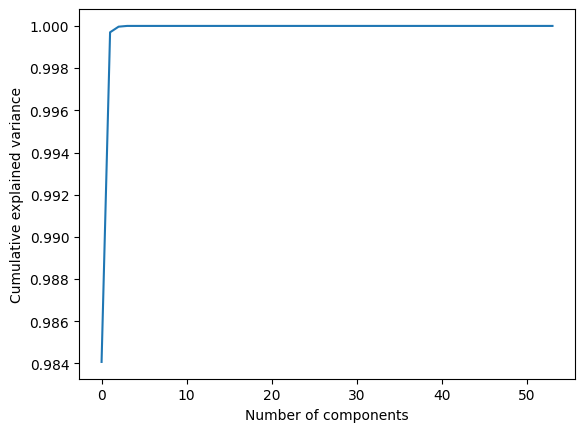

In [3]:
train_powers, test_powers, train_X, test_X = train_test_split(
    powers, X, test_size=0.2, random_state=42
)
val_powers, test_powers, val_X, test_X = train_test_split(
    test_powers, test_X, test_size=0.5, random_state=42
)

cov = np.cov(train_powers.T)
eigenvalues, eigenvectors = np.linalg.eig(cov)
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
cumulative_variance = np.cumsum(eigenvalues) / np.sum(eigenvalues)

plt.plot(cumulative_variance)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.savefig('pca-variance.png', dpi=300, bbox_inches='tight')

n_components = np.where(cumulative_variance >= 0.9999)[0][0] + 1
print(f'Number of components to retain 99.99% variance: {n_components}')

train_pca = train_powers @ eigenvectors[:, :n_components]
val_pca   = val_powers   @ eigenvectors[:, :n_components]
test_pca  = test_powers  @ eigenvectors[:, :n_components]

norm_mean = np.mean(train_pca, axis=0)
norm_std  = np.std(train_pca,  axis=0)

train_pca = (train_pca - norm_mean) / norm_std
val_pca   = (val_pca   - norm_mean) / norm_std
test_pca  = (test_pca  - norm_mean) / norm_std

## 3. Building the Neural Network

The emulator is a small fully-connected (dense) neural network that maps the four input parameters to the $n_\mathrm{PC}$ PCA scores:

$$\hat{\mathbf{s}} = f_\theta(\boldsymbol{\theta})$$

The architecture is:
- **Input layer**: 4 nodes (one per parameter)
- **Hidden layers**: several layers of 64 nodes with ReLU activations
- **Output layer**: $n_\mathrm{PC}$ nodes with a linear activation

We use the **Adam optimiser** with a mean-squared error loss, and apply **early stopping** on the validation set to prevent overfitting. The best model state (lowest validation loss) is saved and restored at the end of training.

Compare this directly with the GP notebook: there, each GP independently learns the same $\boldsymbol{\theta} \to s_i$ mapping for one component at a time. Here, the neural network learns all components jointly in a single model.

Loss: 0.0003  Val: 0.0007:  45%|████▍     | 4488/10000 [00:14<00:18, 302.70it/s]


Early stopping at epoch 4489


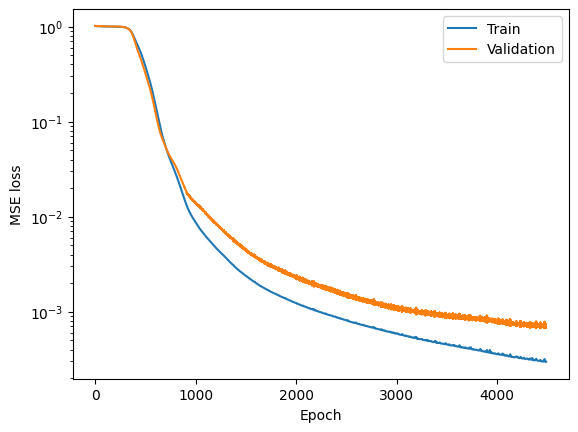

In [4]:
class Emulator(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=64, num_layers=3):
        super(Emulator, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_dim, hidden_dim))
        for _ in range(num_layers):
            self.layers.append(nn.Linear(hidden_dim, hidden_dim))
        self.layers.append(nn.Linear(hidden_dim, output_dim))

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = torch.relu(layer(x))
        return self.layers[-1](x)


input_dim  = train_X.shape[1]     # 4 parameters
output_dim = train_pca.shape[1]   # n_components PCA scores

model     = Emulator(input_dim, output_dim, hidden_dim=32, num_layers=10)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

train_X_tensor   = torch.tensor(train_X,   dtype=torch.float32)
train_pca_tensor = torch.tensor(train_pca, dtype=torch.float32)
val_X_tensor     = torch.tensor(val_X,     dtype=torch.float32)
val_pca_tensor   = torch.tensor(val_pca,   dtype=torch.float32)

n_epochs = 10000
patience = 100
counter  = 0
best_val_loss    = float('inf')
best_model_state = model.state_dict()
train_losses, val_losses = [], []

pbar = tqdm(range(n_epochs))
for epoch in pbar:
    model.train()
    optimizer.zero_grad()
    loss = criterion(model(train_X_tensor), train_pca_tensor)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(val_X_tensor), val_pca_tensor)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_model_state = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

    pbar.set_description(
        f'Loss: {loss.item():.4f}  Val: {val_loss.item():.4f}'
    )

model.load_state_dict(best_model_state)

plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.yscale('log')
plt.legend()
plt.savefig('training-loss.png', dpi=300, bbox_inches='tight')

## 4. Predicting and Reconstructing the Power Spectrum

To generate a prediction at new parameters $\boldsymbol{\theta}_*$:

1. Pass $\boldsymbol{\theta}_*$ through the network to obtain predicted PCA scores $\hat{\mathbf{s}}$.
2. Un-normalise: $\hat{\mathbf{s}} \leftarrow \hat{\mathbf{s}} \odot \sigma + \mu$.
3. Project back through the eigenvectors to recover the power spectrum:

$$\widehat{\Delta^2}(k) = \sum_{i=1}^{n_\mathrm{PC}} \hat{s}_i\, \mathbf{v}_i(k)$$

This reconstruction step is identical to the GP notebook — the emulated PCA scores slot straight in.

Below we compare the neural network predictions against five held-out test simulations.

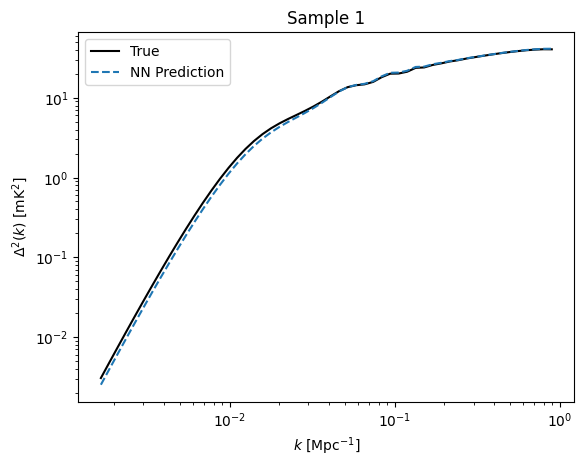

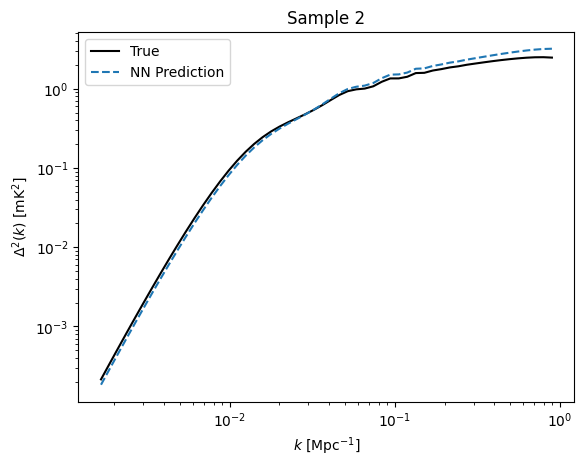

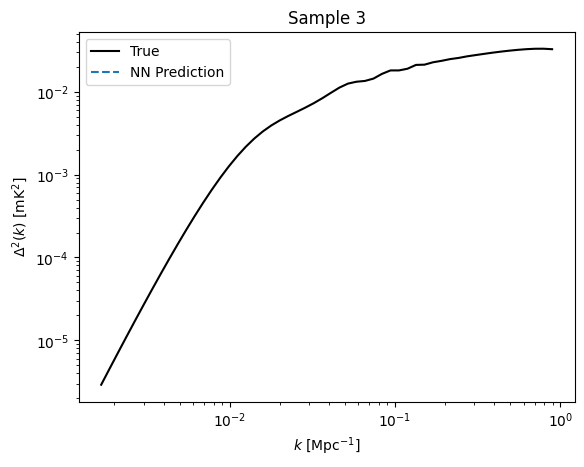

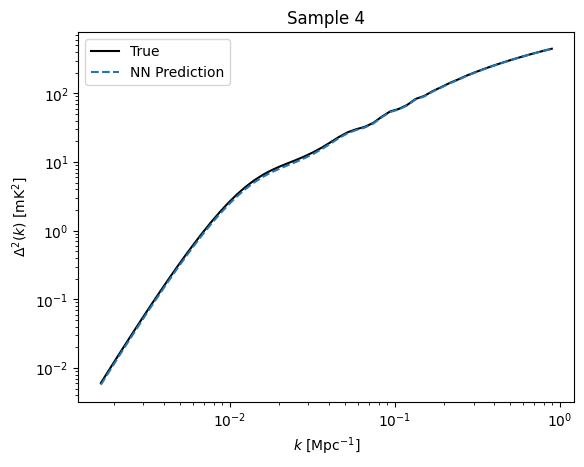

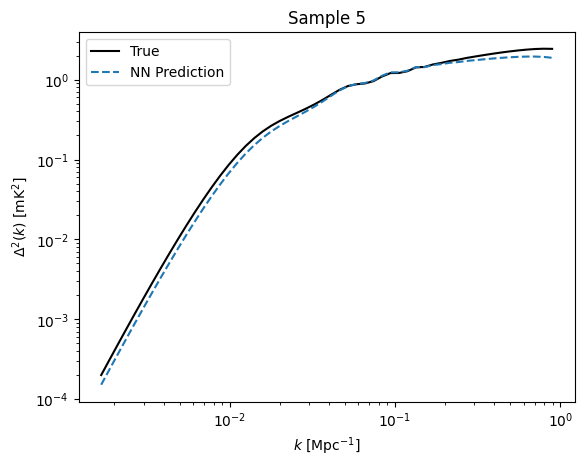

In [5]:
test_X_tensor = torch.tensor(test_X, dtype=torch.float32)

model.eval()
with torch.no_grad():
    test_scores = model(test_X_tensor).numpy()

test_scores = test_scores * norm_std + norm_mean
reconstructed = test_scores @ eigenvectors[:, :n_components].T

for i in range(5):
    plt.figure()
    plt.plot(k, test_powers[i],   label='True',           color='k')
    plt.plot(k, reconstructed[i], label='NN Prediction',  color='C0', linestyle='--')
    plt.xlabel(r'$k\ [\mathrm{Mpc}^{-1}]$')
    plt.ylabel(r'$\Delta^2(k)\ [\mathrm{mK}^2]$')
    plt.loglog()
    plt.legend()
    plt.title(f'Sample {i+1}')
    plt.savefig(f'nn_prediction_{i}.png', dpi=300, bbox_inches='tight')
    plt.show()

## 5. Emulator Accuracy

We quantify accuracy with the **mean fractional residual** per test sample:

$$\epsilon_i = \frac{1}{N_k} \sum_k \frac{|\Delta^2_\mathrm{true}(k) - \widehat{\Delta^2}(k)|}{|\Delta^2_\mathrm{true}(k)|}$$

This is the same metric used in the GP emulator notebook, so you can compare the two approaches directly. A value of $\epsilon = 0.01$ corresponds to 1% average error across $k$-modes.

Mean error:       456.693 %
95th percentile:  2230.327 %


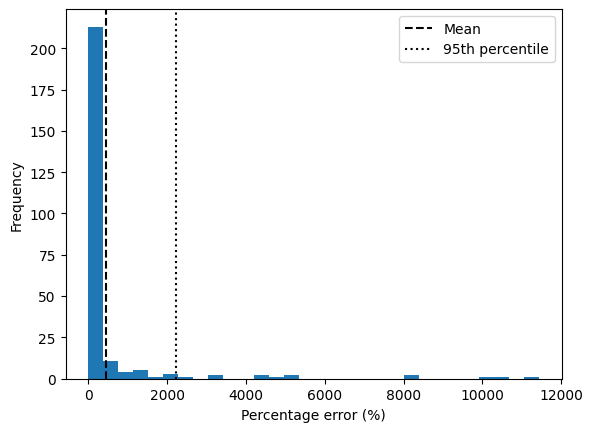

In [6]:
error = [
    100 * np.mean(np.abs(test_powers[i] - reconstructed[i])
        / np.abs(test_powers[i]))
    for i in range(len(test_X))
]
error = np.array(error)

print(f'Mean error:       {np.mean(error):.3f} %')
print(f'95th percentile:  {np.quantile(error, 0.95):.3f} %')

plt.hist(error, bins=30)
plt.axvline(np.mean(error),          label='Mean',          ls='--', c='k')
plt.axvline(np.quantile(error, 0.95),label='95th percentile', ls=':',  c='k')
plt.xlabel('Percentage error (%)')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('errors.png', dpi=300, bbox_inches='tight')
plt.show()